In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np


In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
data.head()

,config_id,index,performance,hp_config.clip_eps,hp_config.ent_coef,hp_config.gae_lambda,hp_config.learning_rate,hp_config.max_grad_norm,hp_config.minibatch_size,hp_config.normalize_advantage,...,hp_config.initial_epsilon,hp_config.learning_starts,hp_config.target_epsilon,hp_config.use_target_network,hp_config.buffer_alpha,hp_config.buffer_beta,hp_config.buffer_epsilon,hp_config.target_update_interval,hp_config.reward_scale,hp_config.tau
0,0,0,4742.1875,0.274407,0.357595,0.920492,0.000530,0.423655,256.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,10,6640.6250,0.191721,0.395863,0.905726,0.000692,0.925597,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,20,2000.0000,0.389078,0.435006,0.995626,0.009904,0.461479,512.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,30,1718.7500,0.472334,0.260924,0.882891,0.000021,0.774234,256.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,40,0.0000,0.306048,0.308467,0.988655,0.002565,0.359508,256.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [5]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False)["_seed_avg"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

data["normed_performance_seedavg"] = data.groupby("env_name", group_keys=False)["_seed_avg"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# 2. THC 

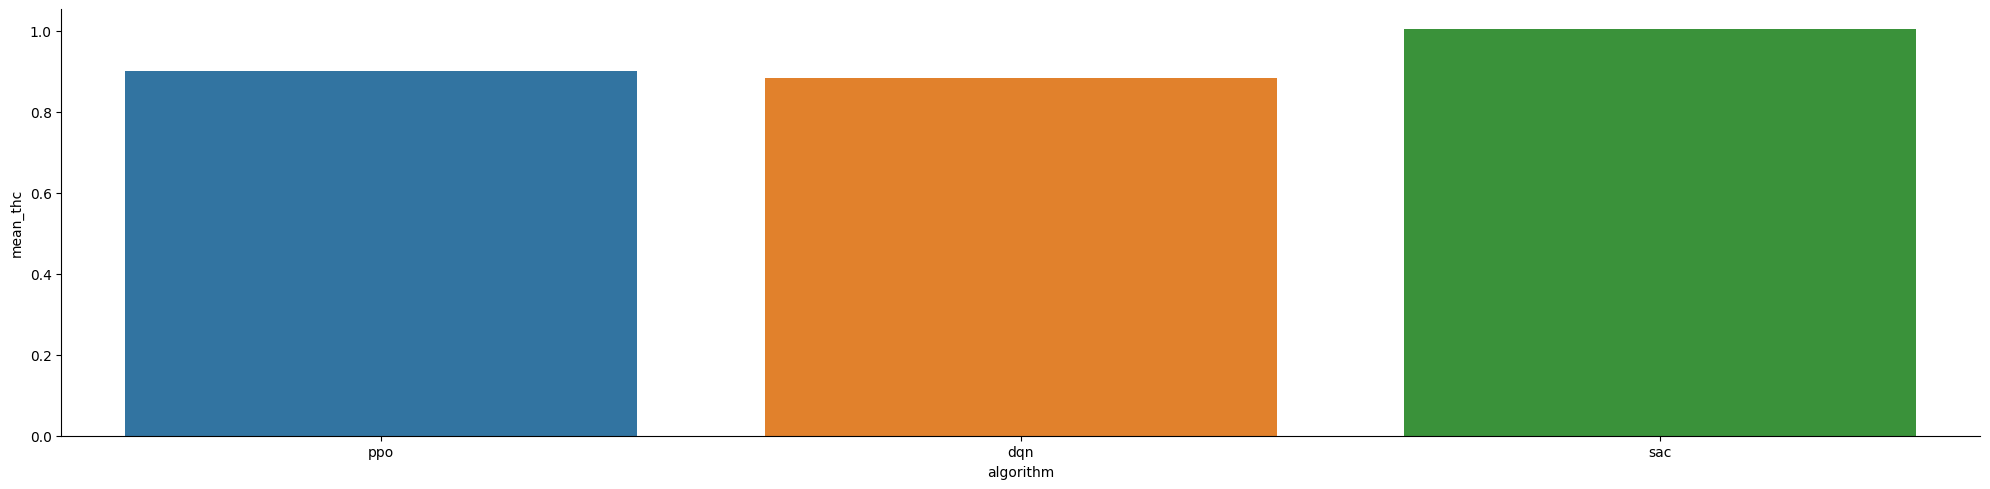

In [ ]:
# THC metric
ranks = []
config_ids = []
environments = []
algorithms = []
for env in envs:
    for algo in algos:
        subset = data[data["algorithm"]==algo]
        env_subset = subset[subset["env_name"]==env]
        if len(env_subset) == 0:
            continue
        mu = env_subset.groupby("config_id")["last_performance"].mean()
        sigma = env_subset.groupby("config_id")["last_performance"].std(ddof=0)
        
        def binary_search_upper(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] > target:
                    high = mid
                else:
                    low = mid + 1
            return low - 1

        def binary_search_lower(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] < target:
                    low = mid + 1
                else:
                    high = mid
            return low

        r_prime = np.argsort(mu + sigma)[::-1]  # Descending order (higher is better)
        mu_prime = mu.iloc[r_prime]
        sigma_prime = sigma.iloc[r_prime]
        lower_bounds = mu_prime - sigma_prime
        upper_bounds = mu_prime + sigma_prime
            
        for config_id in subset["config_id"].unique():
            upper_bound_j = mu[config_id] + sigma[config_id]
            u = binary_search_upper(lower_bounds, upper_bound_j)

            lower_bound_j = mu[config_id] - sigma[config_id]
            l = binary_search_lower(upper_bounds, lower_bound_j)
            config_ids.append(config_id)
            ranks.append((u + l) / 2.0)
            environments.append(env)
            algorithms.append(algo)

thc_data = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "config_id": config_ids,
    "thc_rank": ranks
})
thc_data["ptp"] = thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform(lambda x: x.max() - x.min())

# original:
# thc_data["normed_ptp"] = thc_data["ptp"] / thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform("sum")

thc_data["normed_ptp"] = thc_data["ptp"] / (len(thc_data["config_id"].unique()) - 1) if len(thc_data["config_id"].unique()) > 1 else 0

thc_data["thc_score"] = thc_data.groupby(["env_name", "algorithm"])["normed_ptp"].transform("mean")
thc_data["mean_thc"] = thc_data.groupby(["algorithm"])["thc_score"].transform("mean")
sns.catplot(data=thc_data, x="algorithm", y="mean_thc", hue="algorithm", kind="bar", aspect=4)


In [7]:
thc_data

,env_name,algorithm,config_id,thc_rank,ptp,normed_ptp,thc_score,mean_thc
0,atari_battle_zone,ppo,0,167.5,256.0,1.003922,1.003922,0.899627
1,atari_battle_zone,ppo,1,0.5,256.0,1.003922,1.003922,0.899627
2,atari_battle_zone,ppo,2,90.5,256.0,1.003922,1.003922,0.899627
3,atari_battle_zone,ppo,3,255.5,256.0,1.003922,1.003922,0.899627
4,atari_battle_zone,ppo,4,90.5,256.0,1.003922,1.003922,0.899627
...,...,...,...,...,...,...,...,...
10747,brax_humanoid,sac,251,159.5,256.0,1.003922,1.003922,1.003431
10748,brax_humanoid,sac,252,86.5,256.0,1.003922,1.003922,1.003431
10749,brax_humanoid,sac,253,159.5,256.0,1.003922,1.003922,1.003431
10750,brax_humanoid,sac,254,73.5,256.0,1.003922,1.003922,1.003431
